# Tutorial: the 5-sigma depth of an Argus exposure

This tutorial computes the faintest point source an Argus telescope detects at 5 sigma in one exposure. It follows
the chain that the survey simulator (`argus_sim.Survey`) uses for every exposure: throughput, sky, PSF, noise, then
magnitude. At the end, it checks the numbers against the v5.4 5-year run.

The steps show:

- How the full-system signal efficiency (optics x filter x QE x atmosphere at the exposure's airmass) is built for
  the two survey bands, beta and rho.
- How the sky model turns sky position, time and lunar phase into a sky electron rate per pixel.
- How the delivered PSF and the seeing set the effective number of noise pixels.
- How the 5-sigma limit follows from the noise budget, and how it changes with exposure time, cadence and the Moon.
- How to reproduce the limits recorded in the v5.4 5-year run.

To run it:

- Environment: the ArgusSim virtual environment (`.venv` in the ArgusSim checkout). The notebook uses the default configuration
  (a TOML file in `notebooks/` overrides it), so it logs "No configuration file found, proceeding with defaults".
- Data: the package's throughput curves and sky templates, the delivered PSF file
  (`delivered_psf.fits`, packaged with `argus_sim`), and the visit store of the v5.4 run, set
  as `STORE` in the first code cell (here `~/argussim_runs/canonical-5yr-2028-store`).
- Dates in 2028 lie past the astropy leap-second and polar-motion tables. The notebook silences those warnings; the resulting position errors are below an arcsecond.

Related tutorial: `tutorial_survey_data.ipynb` shows how to read the survey products (depth maps, coverage and
per-night summaries) of the same run.

## Step 1. Load the configuration

All instrument and survey parameters come from `argus_sim.c`, the default configuration. The cell below prints the ones
the depth calculation uses.

In [1]:
%matplotlib inline
import copy
import resource
import time
import warnings
from importlib.resources import files

import astroplan
import astropy.coordinates as crds
import astropy.time as atime
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from erfa import ErfaWarning

from argus_sim import ABPhot, NoiseBudget, SystemThroughput, DeliveredPSF, c
from argus_sim.forward_mc import SOLAR_ACTIVITY_2028_2033
from argus_sim.lightcurve import SurveyRun
from argus_sim.observatory import Observatory, pickering_airmass, seasonal_seeing_params, seeing_at_airmass
from argus_sim.spectral_sky import _load_template, build_band_params, signal_throughput
from argus_sim.survey import build_sharpness_tables, sharpness_at

warnings.filterwarnings("ignore", category=ErfaWarning)  # 2028-2033 lie past the leap-second table
warnings.filterwarnings("ignore", message="Tried to get polar motions")  # and past the IERS table

T_START = time.time()

# 'g' is the Argus beta band.
BANDS = ["g", "rho"]
COLORS = {"g": "tab:green", "rho": "tab:red"}
# The visit store of the v5.4 run: a local directory, or the S3 URI
# s3://schmidt-observatory-system/argus/sim/argsim_5yr_beta_rho_uniform_v5.4/
STORE = "~/argussim_runs/canonical-5yr-2028-store"  
RA, DEC = 223.878, 36.031  # the position followed through the tutorial, in degrees

2026-09-25 16:59:18,836 — argus_sim — INFO — <module>:51 — No configuration file found, proceeding with defaults.


In [2]:
tel, sv = c.telescope, c.survey
print(f"Aperture {tel.aperture_diameter:.0f} mm, collecting area per telescope: {tel.collecting_area:.1f}")
print(f"Plate scale: {tel.plate_scale:.3f} arcsec/pixel ({tel.pixel_size} um pixels)")
print(f"Read noise {tel.readnoise} e-/pixel, dark current {tel.dark_current} e-/s/pixel")
print(f"PSF model: {tel.psf_model}")
print(f"Filter alternation across the array: {c.filter_strategy.options}")
n_exp = int(round((sv.ratchet_len - sv.reset_min) * 60 / sv.base_cadence_s))
print(f"Ratchet: {sv.ratchet_len:.0f} min = {n_exp} x {sv.base_cadence_s:.0f} s exposures + {sv.reset_min:.0f} min reset")
print(f"Bright time (Moon more than {sv.highspeed_start_moonfrac:.0%} illuminated): {sv.fast_cadence_s:.0f} s frames")
print(f"Detection threshold: {sv.detection_snr:.0f} sigma")

Aperture 280 mm, collecting area per telescope: 394.1 cm2
Plate scale: 1.007 arcsec/pixel (3.76 um pixels)
Read noise 1.2 e-/pixel, dark current 0.0022 e-/s/pixel
PSF model: delivered
Filter alternation across the array: ['g', 'rho', 'g', 'rho']
Ratchet: 16 min = 15 x 60 s exposures + 1 min reset
Bright time (Moon more than 96% illuminated): 1 s frames
Detection threshold: 5 sigma


Each telescope has a 280 mm aperture and a plate scale of 1.007 arcsec/pixel.
The detector adds 1.2 e- of read noise and 0.0022 e-/s/pixel of dark current on average. The array alternates beta and rho
filters 1:1 in the baseline configuration, and observes in 16-minute pointings of fifteen 60-s exposures followed by a reset of up to 1 minute. When the Moon is more than 96% illuminated, the cameras swap to 1-s ("fast mode") frames instead of standard 60-s exposures.

## Step 2. The throughput curves

The signal passes through the atmosphere, the optics, the filter and the detector. `SystemThroughput` loads each
curve on a common wavelength grid of 300-1000 nm. The optics enter as one band-averaged efficiency per filter
(`tp.optics`). `ABPhot` converts between AB
magnitudes and photon rates for the per-telescope collecting area in the configuration.


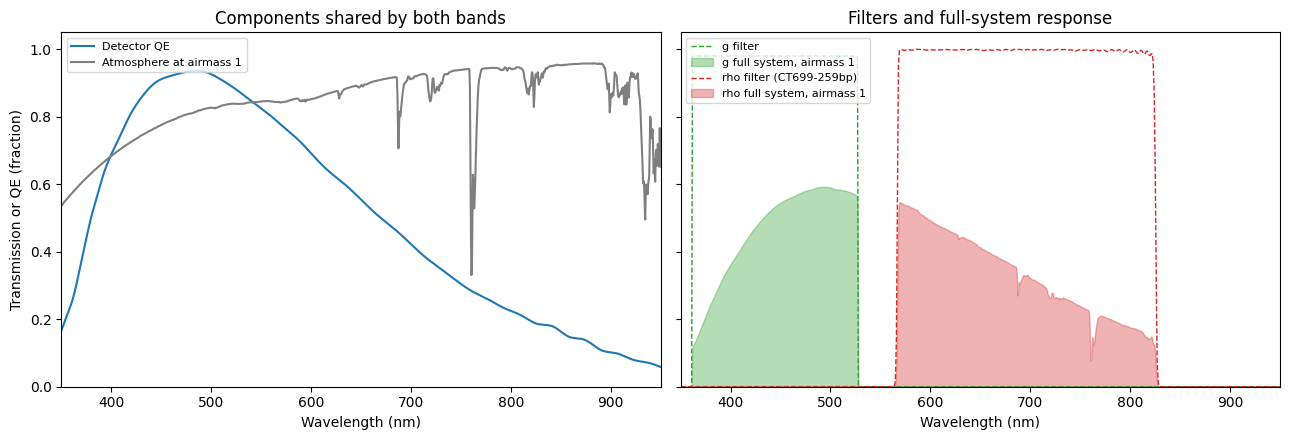

  g: filter 50% points 361-527 nm, optics efficiency 0.787, peak full-system response 0.59 at 494 nm
rho: filter 50% points 567-825 nm, optics efficiency 0.837, peak full-system response 0.55 at 569 nm


In [3]:
tp = SystemThroughput(filters={b: True for b in BANDS})
ab = ABPhot(throughput=tp)  # collecting area from the configuration
wav = tp.wav.to_value(u.nm)
qe = np.asarray(tp.qe_wav, float)
atm1 = np.asarray(tp.filt_wav["atmosphere"], float)

# the delivered rho filter (Chroma CT699-259bp) in the telescope beam, on the same wavelength grid
ct699 = np.genfromtxt(str(files("argus_sim.data") / "throughputs" / "argus_rho_ct699.csv"), delimiter=",", names=True)
filt_plot = {"g": np.asarray(tp.filt_wav["g"], float), "rho": np.interp(wav, ct699["wav_nm"], ct699["T"])}
filt_label = {"g": "g filter", "rho": "rho filter (CT699-259bp)"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].plot(wav, qe, "tab:blue", label="Detector QE")
axes[0].plot(wav, atm1, "tab:gray", label="Atmosphere at airmass 1")
axes[0].set_title("Components shared by both bands")

for b in BANDS:
    filt = filt_plot[b]
    axes[1].plot(wav, filt, color=COLORS[b], ls="--", lw=1, label=filt_label[b])
    axes[1].fill_between(wav, tp.optics[b] * filt * qe * atm1, color=COLORS[b], alpha=0.35, label=f"{b} full system, airmass 1")
    
axes[1].set_title("Filters and full-system response")
for ax in axes:
    ax.set_xlabel("Wavelength (nm)")
    ax.set_xlim(350, 950)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Transmission or QE (fraction)")
fig.tight_layout()
plt.show()

for b in BANDS:
    filt = filt_plot[b]
    edges = wav[np.flatnonzero(np.diff(np.sign(filt - 0.5)))]
    system = tp.optics[b] * filt * qe * atm1
    print(f"{b:>3s}: filter 50% points {edges[0]:.0f}-{edges[-1]:.0f} nm, optics efficiency {tp.optics[b]:.3f}, "
          f"peak full-system response {system.max():.2f} at {wav[np.argmax(system)]:.0f} nm")

The g/beta filter passes 361-527 nm and the rho filter passes 567-825 nm at the 50% points. The full-system
response peaks at 0.59 at 494 nm in g and at 0.55 at 569 nm in rho.

## Step 3. Full-system signal efficiency at the exposure's airmass

`build_band_params` integrates the whole product, filter x optics x QE x
atmosphere^X, over the band for a flat-spectrum (AB) source. This gives eta(X), the detected electrons per photon
that passes the filter, on a grid of airmass X. `signal_throughput(bp, X)` returns eta(X) divided by the band-average QE.


  g: band QE 0.792, eta above the atmosphere 0.609, extinction 0.301 mag/airmass, eta(X=1) 0.462
rho: band QE 0.460, eta above the atmosphere 0.402, extinction 0.141 mag/airmass, eta(X=1) 0.353


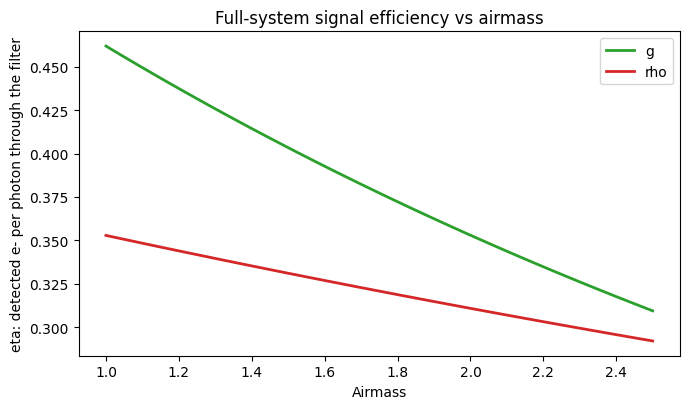

In [4]:
bp = build_band_params(BANDS, tp, ab)


def band_qe(b):
    q = bp[b]["band_qe"]
    return float(getattr(q, "value", q))


for b in BANDS:
    eta0 = bp[b]["signal_tp_no_atm"] * band_qe(b)
    k_ext = -2.5 * np.log10(bp[b]["atm_tp_am1"])
    exact = float(signal_throughput(bp[b], 1.0)) * band_qe(b)
    print(f"{b:>3s}: band QE {band_qe(b):.3f}, eta above the atmosphere {eta0:.3f}, "
          f"extinction {k_ext:.3f} mag/airmass, eta(X=1) {exact:.3f}")

X_grid = np.linspace(1.0, 2.5, 61)
fig, ax = plt.subplots(figsize=(7, 4.2))
for b in BANDS:
    ax.plot(X_grid, signal_throughput(bp[b], X_grid) * band_qe(b), color=COLORS[b], lw=2, label=b)
ax.set_xlabel("Airmass")
ax.set_ylabel("eta: detected e- per photon through the filter")
ax.set_title("Full-system signal efficiency vs airmass")
ax.legend()
fig.tight_layout()
plt.show()

Above the atmosphere, 60.8% of the photons through the g filter become electrons, and 40.2% in
rho. The extinction is 0.301 mag per airmass in g and 0.141 in rho. 

## Step 4. The sky background: components, the Moon and the electron rate

`Observatory.sky_components_at(alt, az, t)` returns the expected sky surface brightness at the site in S10 units (10th-magnitude
stars per square degree in V-band). It has five parts: airglow (scaled by solar activity and airmass), zodiacal light
(the table of Leinert+1998), integrated starlight (galactic latitude), moonlight (Krisciunas & Schaefer 1991) and
artificial light. Each band's `SpectralSky` converts these S10 values to electrons per second per square arcsecond
through the spectral shape of each component.

The cells below use a new moon and a full moon in May-June 2028, within the first year of the v5.4 run, and the solar activity index the run uses for May 2028, when cycle 25 is declining.

The solar activity index S is the one (Walker 1987) used in the ING sky-brightness model. It runs from 0.8 at
solar minimum to 2.0 at solar maximum, and the airglow is (145 + 130 (S - 0.8) / 1.2) S10 per airmass. For
2028-2033 the survey uses one value per month, derived from the 13-month smoothed sunspot number: NOAA's prediction
for cycle 25, then a rise in cycle 26 assumed to match cycle 25 (`SOLAR_ACTIVITY_2028_2033` in
`argus_sim.forward_mc`).

In [5]:
nights = atime.Time("2028-05-01T07:00:00", scale="utc") + np.arange(31) * u.day
illum = np.array([astroplan.moon_illumination(t) for t in nights])
t_new = nights[np.argmin(illum)]
t_full = t_new + 15 * u.day
solar = SOLAR_ACTIVITY_2028_2033[t_new.datetime.month - 1]  # the 2028-2033 prior the v5.4 run uses

cfg = copy.deepcopy(c)
cfg.observatory.solar_activity = solar
obs = Observatory(config=cfg)
for label, t in (("New moon", t_new), ("Full moon", t_full)):
    comp = obs.sky_components_at(np.array([60.0]), np.array([180.0]), t)
    print(f"{label}: {t.iso[:16]} UTC, Moon {astroplan.moon_illumination(t):.0%} illuminated at altitude "
          f"{comp['moon_alt']:.0f} deg, Sun at {comp['sun_alt']:.0f} deg")
print(f"Solar activity index for {t_new.datetime:%B %Y}: {solar:.3f}")

New moon: 2028-05-24 07:00 UTC, Moon 0% illuminated at altitude -35 deg, Sun at -38 deg
Full moon: 2028-06-08 07:00 UTC, Moon 99% illuminated at altitude 31 deg, Sun at -36 deg
Solar activity index for May 2028: 1.170


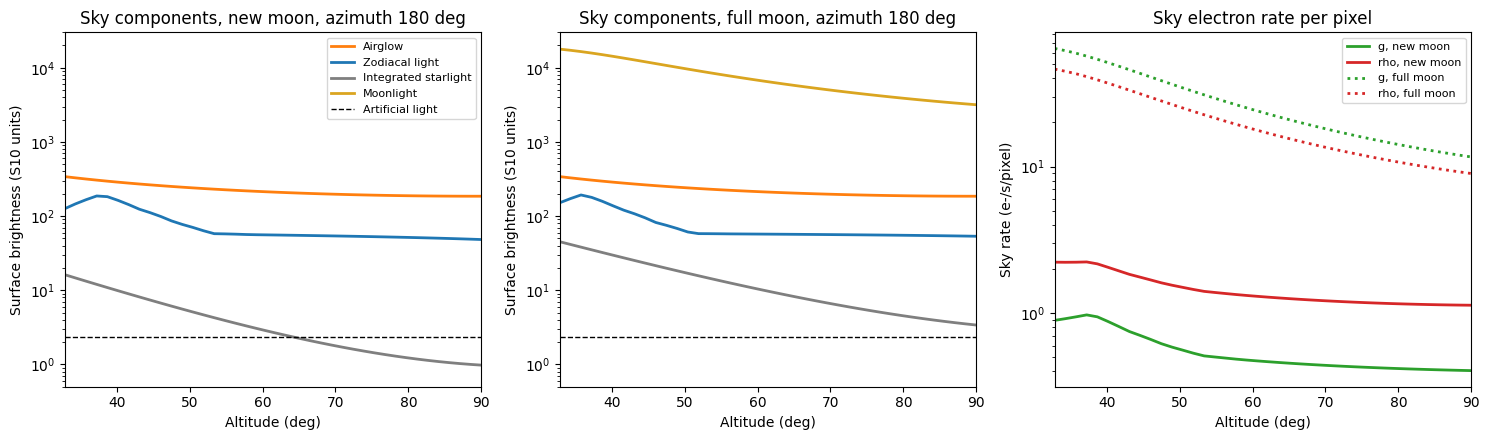

  g at altitude 61 deg: 0.47 e-/s/pixel at new moon, 23.96 at full moon
rho at altitude 61 deg: 1.30 e-/s/pixel at new moon, 17.67 at full moon


In [6]:
alts = np.linspace(c.observatory.min_alt, 90, 40)
azs = np.full_like(alts, 180.0)
plate_scale = c.telescope.plate_scale
parts = [("airglow_s10", "Airglow", "tab:orange"), ("zodiacal_s10", "Zodiacal light", "tab:blue"),
         ("starlight_s10", "Integrated starlight", "tab:gray"), ("moon_s10", "Moonlight", "goldenrod")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sky_rate = {}
for col, (label, t) in enumerate((("new moon", t_new), ("full moon", t_full))):
    comp = obs.sky_components_at(alts, azs, t)
    for key, name, color in parts:
        axes[col].semilogy(alts, np.broadcast_to(comp[key], alts.shape), color=color, lw=2, label=name)
    axes[col].semilogy(alts, np.full_like(alts, comp["artif_s10"]), "k--", lw=1, label="Artificial light")
    axes[col].set_title(f"Sky components, {label}, azimuth 180 deg")
    axes[col].set_ylabel("Surface brightness (S10 units)")
    axes[col].set_ylim(0.5, 3e4)
    for b in BANDS:
        sky_rate[b, label] = bp[b]["sky"].sky_electrons(comp["airglow_s10"], comp["zodiacal_s10"],
                                                       comp["starlight_s10"], comp["moon_s10"], comp["artif_s10"])
        sky_rate[b, label] = sky_rate[b, label] * plate_scale**2
        axes[2].semilogy(alts, sky_rate[b, label], color=COLORS[b], lw=2,
                         ls="-" if label == "new moon" else ":", label=f"{b}, {label}")
axes[0].legend(fontsize=8)
axes[2].set_title("Sky electron rate per pixel")
axes[2].set_ylabel("Sky rate (e-/s/pixel)")
axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("Altitude (deg)")
    ax.set_xlim(alts[0], 90)
fig.tight_layout()
plt.show()

i60 = np.argmin(np.abs(alts - 60))
for b in BANDS:
    print(f"{b:>3s} at altitude {alts[i60]:.0f} deg: {sky_rate[b, 'new moon'][i60]:.2f} e-/s/pixel at new moon, "
          f"{sky_rate[b, 'full moon'][i60]:.2f} at full moon")

At new moon, airglow dominates at every altitude, and the sky rate at 61 deg altitude is 0.47
e-/s/pixel in g and 1.30 in rho. At full moon the rate rises to 23.96 e-/s/pixel in g and 17.67 in rho,
about 50 and 14 times the dark values. The Moon costs g more than rho because scattered
moonlight is blue (a reflected solar spectrum).

### Dark-sky electron sources

The first cell splits the new-moon rate at altitude 60 deg into its components. The second plots the spectral shapes of
the three largest components under the two band responses. The templates are per-component sky spectra from the ESO SkyCalc sky model (Noll+2012, A&A 543, A92;
Jones+2013, A&A 560, A91). They are shapes normalised in V for conversion to and from S10 units. The absolute scale
comes from the S10 values, so the plot shows each template divided by its own peak.

In [7]:
comp = obs.sky_components_at(np.array([60.0]), np.array([180.0]), t_new)
names = ["airglow", "zodiacal", "starlight", "moon", "artif"]
print(f"{'band':>4s}  " + "  ".join(f"{n:>9s}" for n in names) + "   total (e-/s/pixel), new moon, altitude 60 deg")
for b in BANDS:
    sky = bp[b]["sky"]
    rates = [float(np.squeeze(getattr(sky, f"e_per_s10_{n}") * comp[f"{n}_s10"])) * plate_scale**2 for n in names]
    print(f"{b:>4s}  " + "  ".join(f"{r:9.3f}" for r in rates) + f"   {sum(rates):.3f}")

band    airglow   zodiacal  starlight       moon      artif   total (e-/s/pixel), new moon, altitude 60 deg
   g      0.316      0.138      0.013      0.000      0.007   0.474
 rho      1.111      0.183      0.006      0.000      0.007   1.308


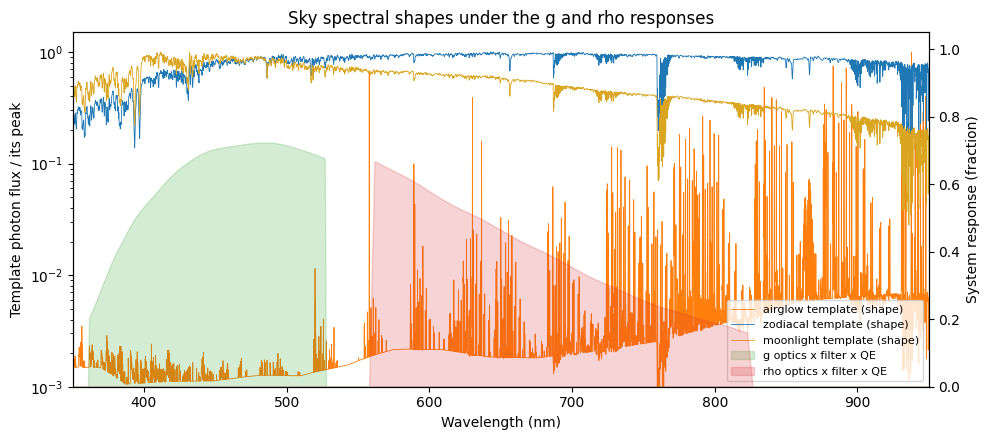

In [8]:
# SpectralSky reads its templates from the package's throughput data directory with the helper
# spectral_sky._load_template, which puts them on the throughput wavelength grid. This cell uses the same loader.
sky_dir = files("argus_sim").joinpath("data", "throughputs")
fig, ax1 = plt.subplots(figsize=(10, 4.5))
for name, color in (("airglow", "tab:orange"), ("zodiacal", "tab:blue"), ("moonlight", "goldenrod")):
    shape = _load_template(str(sky_dir.joinpath(f"{name}_spectrum.csv")), wav)
    band = (wav > 350) & (wav < 950)
    ax1.plot(wav, shape / shape[band].max(), color=color, lw=0.6, label=f"{name} template (shape)")
ax1.set_yscale("log")
ax1.set_ylim(1e-3, 1.5)
ax1.set_xlim(350, 950)
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Template photon flux / its peak")
ax2 = ax1.twinx()
for b in BANDS:
    ax2.fill_between(wav, tp.optics[b] * np.asarray(tp.filt_wav[b], float) * qe, color=COLORS[b], alpha=0.2,
                     label=f"{b} optics x filter x QE")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("System response (fraction)")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower right")
ax1.set_title("Sky spectral shapes under the g and rho responses")
fig.tight_layout()
plt.show()

Airglow gives 0.316 of the 0.474 e-/s/pixel in g (67%) and 1.111 of the 1.308 e-/s/pixel in rho
(85%). The OH airglow bands crowd the red half of rho, so the rho sky is ~2.8 times brighter than the g sky
on a dark night. Zodiacal light is the second largest term in both bands.

> **Try it.** In Step 4, set `solar = 2.0` (solar maximum) or `0.8` (solar minimum), rebuild `obs`, and rerun the
> cells down to Step 7. The airglow term is (145 + 130 (S - 0.8) / 1.2) S10 per airmass, so at solar maximum the
> airglow is about 1.5 times its May 2028 value. Expect the dark sky to rise by roughly 40% in rho and 30% in g, and
> both limits to lose one to two tenths of a magnitude. The phase of the solar cycle during the survey matters at this level.

## Step 5. The delivered PSF

The default PSF model is `DeliveredPSF` (`telescope.psf_model = "delivered"`). It reads images of the delivered
PSF at 7 field angles from the optical axis, one set for g and one for rho, sampled at half a detector pixel. The
images are broadened to the delivered image-quality specification, which allows for pixel-grid, local-seeing and
tracking losses. Binned to detector pixels, their EE50 diameters lie between 2 and 3 pixels and reach 3 pixels at
the field corners. The atmospheric seeing of each exposure is added on top: each image is convolved with a Moffat
seeing kernel and binned to detector pixels.

### One PSF with seeing

The seeing at the site follows a seasonal lognormal model: a median zenith FWHM of 0.93 arcsec from March to
November and 1.24 arcsec in winter (Barker+2003). The seeing at airmass X is `seeing_at_airmass(seeing_zenith, X)` =
seeing_zenith x X^0.6.

The quantity that sets the noise is the sharpness S = sum(P_i²) of the pixelated PSF, normalised to unit flux. The
background noise in PSF-fitting photometry is contributed by ~1/S pixels.

Zenith seeing 0.93 arcsec -> 1.01 arcsec at airmass 1.15
g at 1.33 deg: HFD 2.68 arcsec, sharpness 0.0615, noise pixels 1/S = 16.3


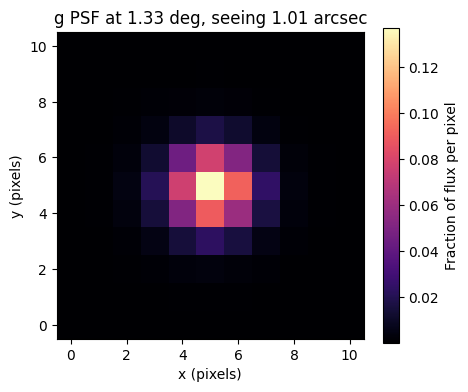

In [9]:
psf = DeliveredPSF.from_config(c)  
see_z = seasonal_seeing_params(t_new)[0]  # the site's median zenith seeing for May, arcsec
X0, fa0 = 1.15, 1.33  # a typical airmass, and the median field angle of a detector pixel (deg)
see_X = float(seeing_at_airmass(see_z, X0))
stamp, hfd = psf.with_seeing(see_X, band="g", field_angle_deg=fa0, pixel_phase=(0.0, 0.0))

print(f"Zenith seeing {see_z:.2f} arcsec -> {see_X:.2f} arcsec at airmass {X0}")
S = np.sum(stamp**2)
print(f"g at {fa0} deg: HFD {hfd:.2f} arcsec, sharpness {S:.4f}, noise pixels 1/S = {1 / S:.1f}")

cy, cx = np.unravel_index(np.argmax(stamp), stamp.shape)
fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(stamp[cy - 5:cy + 6, cx - 5:cx + 6], origin="lower", cmap="magma")
fig.colorbar(im, ax=ax, label="Fraction of flux per pixel")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title(f"g PSF at {fa0} deg, seeing {see_X:.2f} arcsec")
fig.tight_layout()
plt.show()

At airmass 1.15 the 0.93 arcsec zenith seeing becomes 1.01 arcsec. The delivered PSF then has a
half-flux diameter of 2.68 arcsec and 1/S = 16.3 noise pixels.

## Step 6. Sharpness tables

Computing a PSF for every exposure is slow. `Survey` instead builds a table of sharpness per band over the 7 tabulated
field angles and 16 seeing values from 0.4 to 4 arcsec, averaged over four pixel phases (`survey.build_sharpness_tables`).
Each exposure then looks up its sharpness at each field angle and at its seeing and airmass
(`survey.sharpness_at`). The cell below builds the same tables.

Built sharpness tables in 1 s: 7 field angles x 16 seeing values per band


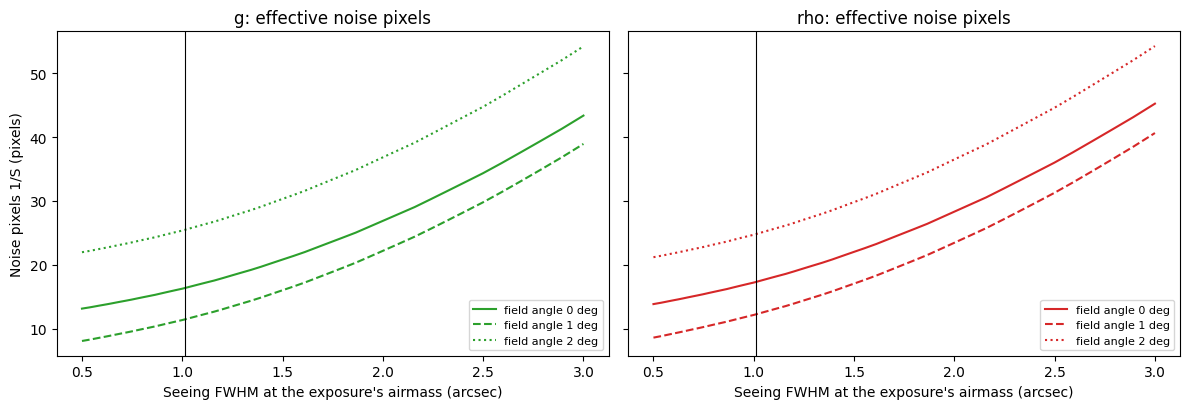

  g: 1/S = 16.3 pixels at 1.33 deg and 1.01 arcsec
rho: 1/S = 16.1 pixels at 1.33 deg and 1.01 arcsec


In [10]:
t0 = time.time()
tables = build_sharpness_tables(psf, BANDS)
print(f"Built sharpness tables in {time.time() - t0:.0f} s: "
      f"{tables['g'][2].shape[0]} field angles x {tables['g'][2].shape[1]} seeing values per band")

seeing_grid = np.geomspace(0.5, 3.0, 50)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, b in zip(axes, BANDS):
    for fa, ls in ((0.0, "-"), (1.0, "--"), (2.0, ":")):
        ax.plot(seeing_grid, 1 / sharpness_at(tables[b], fa, seeing_grid), color=COLORS[b], ls=ls,
                label=f"field angle {fa:.0f} deg")
    ax.axvline(see_X, color="k", lw=0.8)
    ax.set_xlabel("Seeing FWHM at the exposure's airmass (arcsec)")
    ax.set_title(f"{b}: effective noise pixels")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Noise pixels 1/S (pixels)")
fig.tight_layout()
plt.show()
for b in BANDS:
    print(f"{b:>3s}: 1/S = {1 / float(np.squeeze(sharpness_at(tables[b], fa0, see_X))):.1f} pixels at {fa0} deg "
          f"and {see_X:.2f} arcsec")

The tables take a few seconds to build. The number of noise pixels grows quickly with the seeing once
the seeing is larger than the optical image. At the median field angle (1.33 deg) and 1.01 arcsec seeing, 1/S is
16.3 pixels in g and 16.1 in rho. The phase-averaged table value matches the single PSF of Step 5.

## Step 7. The 5-sigma limit of one 60-s exposure

The chain comes together for typical dark-time conditions:

- the new-moon night of 2028-05-24, with the Moon and the Sun below the horizon;
- the tutorial position (RA 223.878, Dec 36.031) at airmass 1.15;
- the May median zenith seeing, 0.93 arcsec;
- the median field angle of a detector pixel, 1.33 deg;
- photometric sky (transparency 1).

`NoiseBudget.get_flux_at_snr` solves the CCD equation, SNR = S_e / sqrt(S_e + B / S), for the detected source
electrons S_e at SNR = 5. Here B = read noise² + dark + sky is the background variance per pixel of one exposure and
S is the sharpness. The function returns the electrons above the atmosphere, which are divided by the exposure time and the
band QE and converted to an AB magnitude against the filter-only zero point. `limit_mag` below follows `Survey`
line for line.

In [11]:
site = obs.el
night = t_new - 5 * u.hour + np.arange(0, 11 * 60, 2) * u.minute
frame = crds.AltAz(obstime=night, location=site)
target = crds.SkyCoord(RA * u.deg, DEC * u.deg).transform_to(frame)
sun_alt = crds.get_sun(night).transform_to(frame).alt.deg
moon_alt = crds.get_body("moon", night).transform_to(frame).alt.deg
X_night = pickering_airmass(target.alt.deg)
ok = (sun_alt < -18) & (moon_alt < 0)
i = np.flatnonzero(ok)[np.argmin(np.abs(X_night[ok] - X0))]
t_obs, alt_obs, az_obs = night[i], target.alt.deg[i], target.az.deg[i]
print(f"{t_obs.iso[:16]} UTC: position at altitude {alt_obs:.1f} deg (airmass {X_night[i]:.3f}), "
      f"Sun {sun_alt[i]:.0f} deg, Moon {moon_alt[i]:.0f} deg")
comp_obs = obs.sky_components_at(np.array([alt_obs]), np.array([az_obs]), t_obs)

2028-05-24 08:04 UTC: position at altitude 60.3 deg (airmass 1.150), Sun -35 deg, Moon -32 deg


In [12]:
nb = NoiseBudget(read_noise=tel.readnoise * u.electron, dark_current=tel.dark_current * u.electron / u.second)


def sky_per_pixel(b, comp, transparency=1.0):
    """Sky electron rate per pixel (e-/s) in band b from the S10 components."""
    rate = bp[b]["sky"].sky_electrons(comp["airglow_s10"], comp["zodiacal_s10"], comp["starlight_s10"],
                                      comp["moon_s10"], comp["artif_s10"], transparency=transparency)
    return np.asarray(rate, float) * plate_scale**2


def limit_mag(b, sky_e, X, seeing_zenith, field_angle, transparency=1.0, exptime=60.0, coadd_n=1, snr=5.0):
    """5-sigma AB limit as Survey computes it; returns (mag, noise budget, throughput, sharpness)."""
    T = np.squeeze(signal_throughput(bp[b], X) * transparency)
    S = np.squeeze(sharpness_at(tables[b], field_angle, seeing_at_airmass(seeing_zenith, X)))
    e_above, budget = nb.get_flux_at_snr(snr=snr, psf=None, eskyflux=sky_e * u.electron / u.second,
                                         exptime=exptime * u.second, signal_throughput=T, coadd_n=coadd_n,
                                         sharpness=S)
    photons = e_above / (exptime * u.second) / bp[b]["band_qe"]
    mag = ab.mag_from_photons(b, photons)
    return np.squeeze(np.asarray(getattr(mag, "value", mag), float)), budget, T, S

In [13]:
typical = {}
for b in BANDS:
    sky_e = sky_per_pixel(b, comp_obs)
    m, bud, T, S = limit_mag(b, sky_e, X0, see_z, fa0)
    typical[b] = float(np.squeeze(m))
    B = tel.readnoise**2 + tel.dark_current * 60 + float(np.squeeze(sky_e)) * 60
    print(f"--- {b}, 60 s, new moon, airmass {X0}, zenith seeing {see_z} arcsec, field angle {fa0} deg")
    print(f"  sky {float(np.squeeze(sky_e)):.3f} e-/s/pixel; background variance B = {B:.1f} e-^2/pixel per exposure")
    print(f"  signal throughput T = eta(X)/band QE = {float(T):.3f}; sharpness S = {float(S):.4f} (1/S = {1 / float(S):.1f} pixels)")
    print(f"  background noise sqrt(B/S) = {np.sqrt(B / float(S)):.1f} e-")
    print(f"  detected source electrons at 5 sigma: {float(np.squeeze(bud['source_shot'])) ** 2:.0f} e-")
    print(f"  5-sigma limit: {typical[b]:.2f} AB mag")

--- g, 60 s, new moon, airmass 1.15, zenith seeing 0.93 arcsec, field angle 1.33 deg
  sky 0.416 e-/s/pixel; background variance B = 26.5 e-^2/pixel per exposure
  signal throughput T = eta(X)/band QE = 0.560; sharpness S = 0.0614 (1/S = 16.3 pixels)
  background noise sqrt(B/S) = 20.8 e-
  detected source electrons at 5 sigma: 117 e-
  5-sigma limit: 20.65 AB mag
--- rho, 60 s, new moon, airmass 1.15, zenith seeing 0.93 arcsec, field angle 1.33 deg
  sky 1.238 e-/s/pixel; background variance B = 75.9 e-^2/pixel per exposure
  signal throughput T = eta(X)/band QE = 0.753; sharpness S = 0.0620 (1/S = 16.1 pixels)
  background noise sqrt(B/S) = 35.0 e-
  detected source electrons at 5 sigma: 188 e-
  5-sigma limit: 19.92 AB mag


On this dark night a 60-s exposure reaches 20.65 mag in g and 19.92 mag in rho. The g limit is
deeper because its sky is darker (0.416 against 1.238 e-/s/pixel, so the background noise is 20.8 e- against
35.0 e-) and its system throughput is higher. The sky dominates B in both bands: 25.0 of the 26.5 e-² in g comes from the sky.

> **Try it.** Call `limit_mag("g", sky_per_pixel("g", comp_obs), 1.15, 1.24, 1.33)[0]` to use the winter median
> zenith seeing of 1.24 arcsec. Expect the g limit to drop by a few tenths of a magnitude, since the number of noise
> pixels grows with the seeing. Then try field angles of 0.0 and 2.0 deg to see what the edge of the field costs.

## Step 8. Exposure time and the noise regimes

The calculation is repeated from 0.1 s to 300 s. The left panel splits the noise variance at the 5-sigma limit into its
four terms. The `NoiseBudget` dictionary returns the read-noise and source terms as standard deviations and the sky
and dark terms as variances, so the first two are squared before the sum.

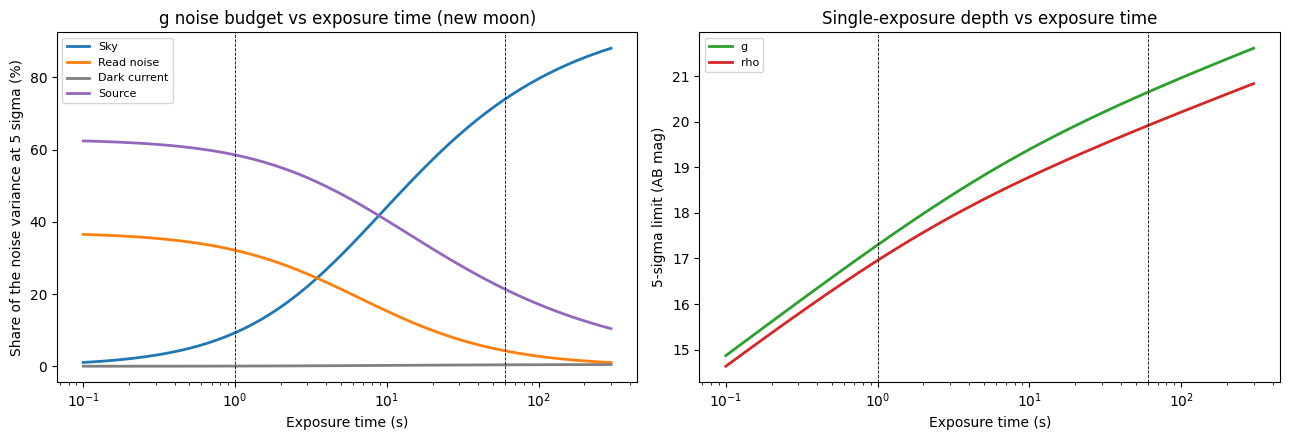

g at 60 s: sky 74%, read 4.3% of the variance; at 1 s the read noise share is 32%


In [14]:
texp = np.geomspace(0.1, 300, 60)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
terms = (("sky_electrons", "Sky", "tab:blue"), ("readnoise", "Read noise", "tab:orange"),
         ("dark_electrons", "Dark current", "tab:gray"), ("source_shot", "Source", "tab:purple"))
depth_vs_t = {}

for b in BANDS:
    sky_e = float(np.squeeze(sky_per_pixel(b, comp_obs)))
    rows = [limit_mag(b, sky_e, X0, see_z, fa0, exptime=t) for t in texp]
    depth_vs_t[b] = np.array([float(np.squeeze(r[0])) for r in rows])
    axes[1].plot(texp, depth_vs_t[b], color=COLORS[b], lw=2, label=b)
    if b == "g":
        # variances: read noise and source shot are returned as sigmas, sky and dark as variances
        var = {"sky_electrons": [float(np.squeeze(r[1]["sky_electrons"])) for r in rows],
               "readnoise": [float(np.squeeze(r[1]["readnoise"])) ** 2 for r in rows],
               "dark_electrons": [float(np.squeeze(r[1]["dark_electrons"])) for r in rows],
               "source_shot": [float(np.squeeze(r[1]["source_shot"])) ** 2 for r in rows]}
        total = np.sum([var[k] for k in var], axis=0)
        for key, name, color in terms:
            axes[0].plot(texp, 100 * np.array(var[key]) / total, color=color, lw=2, label=name)
            
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Exposure time (s)")
    for t in (1, 60):
        ax.axvline(t, color="k", lw=0.6, ls="--")
    ax.legend(fontsize=8)
    
axes[0].set_ylabel("Share of the noise variance at 5 sigma (%)")
axes[0].set_title("g noise budget vs exposure time (new moon)")
axes[1].set_ylabel("5-sigma limit (AB mag)")
axes[1].set_title("Single-exposure depth vs exposure time")
fig.tight_layout()
plt.show()

k60 = np.argmin(np.abs(texp - 60))
print(f"g at 60 s: sky {100 * var['sky_electrons'][k60] / total[k60]:.0f}%, read {100 * var['readnoise'][k60] / total[k60]:.1f}% "
      f"of the variance; at 1 s the read noise share is "
      f"{100 * np.interp(1, texp, np.array(var['readnoise']) / total):.0f}%")

At 60 s the sky gives 74% of the variance in g and read noise only 4.3%. At 1 s the read noise
share rises to 32%, and the source's own shot noise is the largest term. In the sky-limited regime the limit gains 1.25 log10(t2 / t1) mag, and the curves on the right
approach that slope at long exposures.

## Step 9. Frames, slots and pointings

The survey records its data in 60-s slots. In dark time, a slot is one 60-s exposure. In bright time (Moon more than
96% illuminated), a slot is sixty 1-s frames. A 16-minute pointing (a ratchet in the code) holds fifteen slots, plus a 1-minute ratchet-back block that could be used for
antisidereal observing, which ArgusSim does not model. The `coadd_n` argument stacks frames. The cell prints four cases for
the same dark night.

In [15]:
for b in BANDS:
    sky_e = float(np.squeeze(sky_per_pixel(b, comp_obs)))
    one = float(np.squeeze(limit_mag(b, sky_e, X0, see_z, fa0, exptime=1.0)[0]))
    slot = float(np.squeeze(limit_mag(b, sky_e, X0, see_z, fa0, exptime=1.0, coadd_n=60)[0]))
    ratchet = float(np.squeeze(limit_mag(b, sky_e, X0, see_z, fa0, exptime=60.0, coadd_n=15)[0]))
    print(f"{b:>3s}: 1-s frame {one:.2f}, sixty 1-s frames {slot:.2f}, one 60-s exposure {typical[b]:.2f}, "
          f"fifteen 60-s exposures {ratchet:.2f} AB mag")

  g: 1-s frame 17.30, sixty 1-s frames 19.94, one 60-s exposure 20.65, fifteen 60-s exposures 22.21 AB mag
rho: 1-s frame 16.96, sixty 1-s frames 19.53, one 60-s exposure 19.92, fifteen 60-s exposures 21.44 AB mag


One 1-s frame reaches 17.30 mag in g. Sixty of them stacked reach 19.94 mag, 0.71 mag short of a
single 60-s exposure (20.65 mag), because each frame adds read noise. Fifteen 60-s exposures
(one 16-minute pointing) reach 22.21 mag in g and 21.44 mag in rho in that band. The survey data tutorial counts how many exposures a position gets in each band.

## Step 10. A month of observing

The cell computes the limit every night for 30 nights from the new moon, at 07:00 UTC, altitude 60 deg and azimuth 180 deg.
The seeing, field angle and transparency stay fixed so that only the Moon changes. For each night the plot shows the 60-s
exposure, the stack of sixty 1-s frames and a single 1-s frame. The shading marks the nights on which the survey
switches to 1-s frames.

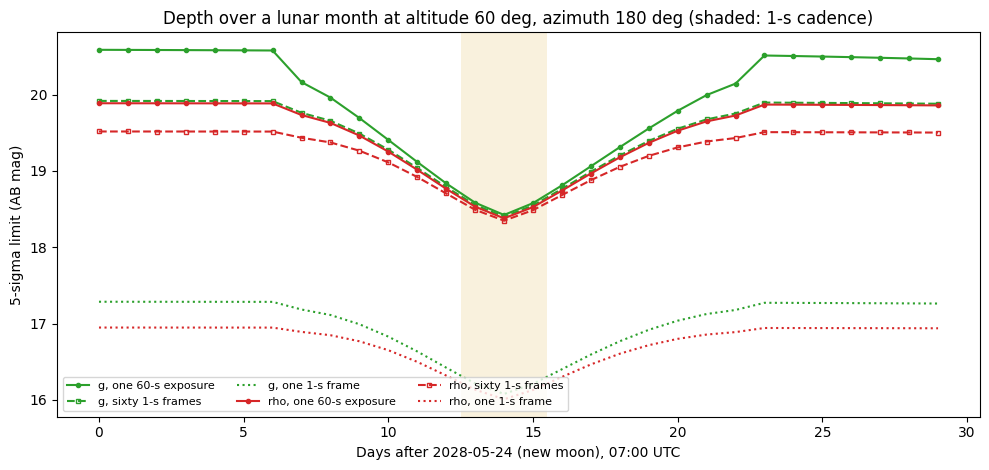

3 of 30 nights use 1-s frames (Moon > 96% illuminated)
  g: 60-s limit 20.59 at best, 18.42 at worst; on the 1-s nights the 60-frame slot is 0.03 mag shallower than a 60-s exposure (median)
rho: 60-s limit 19.89 at best, 18.38 at worst; on the 1-s nights the 60-frame slot is 0.04 mag shallower than a 60-s exposure (median)


In [16]:
month = t_new + np.arange(30) * u.day
alt_m, az_m = np.array([60.0]), np.array([180.0])
rec = {k: [] for k in ("illum", "g60", "rho60", "g1", "rho1", "gslot", "rhoslot")}
for t in month:
    comp = obs.sky_components_at(alt_m, az_m, t)
    rec["illum"].append(astroplan.moon_illumination(t))
    for b in BANDS:
        sky_e = float(np.squeeze(sky_per_pixel(b, comp)))
        X = float(pickering_airmass(60.0))
        rec[f"{b}60"].append(float(np.squeeze(limit_mag(b, sky_e, X, see_z, fa0)[0])))
        rec[f"{b}1"].append(float(np.squeeze(limit_mag(b, sky_e, X, see_z, fa0, exptime=1.0)[0])))
        rec[f"{b}slot"].append(float(np.squeeze(limit_mag(b, sky_e, X, see_z, fa0, exptime=1.0, coadd_n=60)[0])))
rec = {k: np.array(v) for k, v in rec.items()}
fast = rec["illum"] > sv.highspeed_start_moonfrac
day = np.arange(30)

fig, ax = plt.subplots(figsize=(10, 4.8))
for b in BANDS:
    ax.plot(day, rec[f"{b}60"], "o-", color=COLORS[b], ms=3, label=f"{b}, one 60-s exposure")
    ax.plot(day, rec[f"{b}slot"], "s--", color=COLORS[b], ms=3, mfc="none", label=f"{b}, sixty 1-s frames")
    ax.plot(day, rec[f"{b}1"], ":", color=COLORS[b], label=f"{b}, one 1-s frame")
for d in day[fast]:
    ax.axvspan(d - 0.5, d + 0.5, color="goldenrod", alpha=0.15, lw=0)
ax.set_xlabel(f"Days after {t_new.iso[:10]} (new moon), 07:00 UTC")
ax.set_ylabel("5-sigma limit (AB mag)")
ax.set_title("Depth over a lunar month at altitude 60 deg, azimuth 180 deg (shaded: 1-s cadence)")
ax.legend(fontsize=8, ncol=3, loc="lower left")
fig.tight_layout()
plt.show()
print(f"{fast.sum()} of 30 nights use 1-s frames (Moon > {sv.highspeed_start_moonfrac:.0%} illuminated)")
for b in BANDS:
    print(f"{b:>3s}: 60-s limit {rec[f'{b}60'].max():.2f} at best, {rec[f'{b}60'].min():.2f} at worst; on the 1-s nights "
          f"the 60-frame slot is {np.median(rec[f'{b}60'][fast] - rec[f'{b}slot'][fast]):.2f} mag shallower "
          f"than a 60-s exposure (median)")

Over the month, the g-band limit of a 60-s exposure ranges from 20.59 to 18.42 mag and the rho
limit from 19.89 to 18.38 mag. The Moon costs g more. On 3 of the 30 nights the Moon is more than 96% illuminated
and the survey takes 1-s frames. 

## Step 11. Compare with the v5.4 5-year run

The v5.4 run simulated five years from 2028 with this same chain. Its visit store (`STORE` constant defined above)
records every exposure that covered each position. `argus_sim.lightcurve.SurveyRun.visits` returns one
row per 60-s slot and OTA with the exposure's conditions: airmass, zenith seeing, field angle, transparency,
throughput and background noise. `run.limit_mag(vis, per="frame")` turns each row into the 5-sigma limit of one frame.
The cell keeps the 60-s rows.

In [18]:
run = SurveyRun(STORE)
vis = run.visits(RA, DEC)
d = vis[vis["exptime_s"] == 60.0]
lim_run = run.limit_mag(d, per="frame")
print(run)
print(f"{len(vis)} slots cover the position: {len(d)} are 60-s exposures, {np.sum(vis['exptime_s'] == 1.0)} are 1-s slots")
for b in BANDS:
    s = d["band"] == b
    print(f"{b:>3s}: {s.sum()} 60-s exposures, median 5-sigma limit {np.median(lim_run[s]):.2f} AB mag "
          f"(16-84%: {np.percentile(lim_run[s], 16):.2f}-{np.percentile(lim_run[s], 84):.2f})")

SurveyRun('/home/user/argussim_runs/canonical-5yr-2028-store': 43397 ratchets, 116695 tiles, 2,526,741,344 pair rows, bands ['g', 'rho'])
291942 slots cover the position: 257581 are 60-s exposures, 34361 are 1-s slots
  g: 128296 60-s exposures, median 5-sigma limit 20.43 AB mag (16-84%: 19.37-20.76)
rho: 129285 60-s exposures, median 5-sigma limit 19.75 AB mag (16-84%: 19.17-20.06)


The tutorial position was covered by 291,942 slots in five years: 257,581 60-s exposures and 34,361 1-s
slots. The median 60-s limit is 20.43 mag in g and 19.75 mag in rho. The typical dark-night values from Step 7 are
0.22 mag deeper in g and 0.16 mag deeper in rho. 

### Split the run by conditions

The run's median mixes all conditions. The cell computes the Moon's altitude at the middle of each ratchet and splits the rows
into three sets: all 60-s exposures, those with the Moon below the horizon, and those that are also photometric. The
table gives the median limit and the median conditions of each set.

In [19]:
rat = run.ratchets
ids = np.unique(np.asarray(d["ratchet"]))
pos = np.searchsorted(np.asarray(rat["ratchet"]), ids)
t_mid = atime.Time(np.asarray(rat["mjd_mid"])[pos], format="mjd", scale="utc")
moon_up = crds.get_body("moon", t_mid).transform_to(crds.AltAz(obstime=t_mid, location=site)).alt.deg
row_of = np.searchsorted(ids, np.asarray(d["ratchet"]))
moon_alt_row = moon_up[row_of]
photometric = np.asarray(d["transparency"]) == 1.0
subsets = {"all 60-s exposures": np.ones(len(d), bool),
           "Moon below horizon": moon_alt_row < 0,
           "Moon below horizon, photometric": (moon_alt_row < 0) & photometric}

print(f"{'subset':34s} {'band':>4s} {'N':>6s} {'limit':>6s} {'airmass':>7s} {'seeing':>6s} {'f.angle':>7s} {'transp':>6s}")
for name, sel in subsets.items():
    for b in BANDS:
        s = sel & (np.asarray(d["band"]) == b)
        print(f"{name:34s} {b:>4s} {s.sum():6d} {np.median(lim_run[s]):6.2f} {np.median(d['airmass'][s]):7.3f} "
              f"{np.median(d['seeing_zenith'][s]):6.2f} {np.median(d['field_angle'][s]):7.2f} "
              f"{np.mean(d['transparency'][s]):6.3f}")
print(f"Photometric (transparency 1): {np.mean(np.asarray(d['transparency']) == 1.0):.0%} of the 60-s exposures")

subset                             band      N  limit airmass seeing f.angle transp
all 60-s exposures                    g 128296  20.43   1.141   0.96    1.33  0.922
all 60-s exposures                  rho 129285  19.75   1.155   0.96    1.36  0.924
Moon below horizon                    g  76627  20.63   1.140   0.96    1.33  0.925
Moon below horizon                  rho  76703  19.89   1.152   0.96    1.36  0.923
Moon below horizon, photometric       g  60451  20.67   1.139   0.96    1.33  1.000
Moon below horizon, photometric     rho  60488  19.93   1.150   0.96    1.36  1.000
Photometric (transparency 1): 78% of the 60-s exposures


The median airmass (1.14-1.16), zenith seeing (0.96 arcsec) and field angle (1.33-1.36 deg)
are the same in every set and close to the Step 7 choices. The sets differ in the Moon and the clouds. Dropping the
exposures taken with the Moon up deepens the g median from 20.43 to 20.63 mag. Dropping the cloudy ones as well
brings it to 20.67 mag. In rho the same steps give 19.75, 19.89 and 19.93 mag.

### The distributions

The histograms show the run's limits for all 60-s exposures and for the Moon-down photometric set, with the Step 7 values.

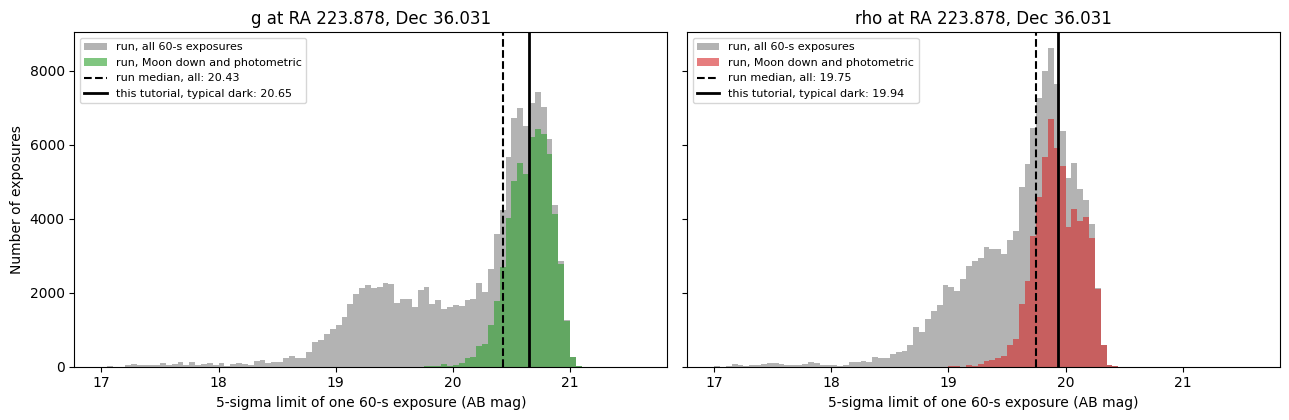

  g: typical dark 20.65; run median 20.43 (all), 20.67 (Moon down, photometric)
rho: typical dark 19.94; run median 19.75 (all), 19.93 (Moon down, photometric)


In [20]:
dark = subsets["Moon below horizon, photometric"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
bins = np.arange(17.0, 21.6, 0.05)
for ax, b in zip(axes, BANDS):
    s = np.asarray(d["band"]) == b
    ax.hist(lim_run[s], bins=bins, color="0.7", label="run, all 60-s exposures")
    ax.hist(lim_run[s & dark], bins=bins, color=COLORS[b], alpha=0.6, label="run, Moon down and photometric")
    ax.axvline(np.median(lim_run[s]), color="k", ls="--", label=f"run median, all: {np.median(lim_run[s]):.2f}")
    ax.axvline(typical[b], color="k", lw=2, label=f"this tutorial, typical dark: {typical[b]:.2f}")
    ax.set_xlabel("5-sigma limit of one 60-s exposure (AB mag)")
    ax.set_title(f"{b} at RA {RA}, Dec {DEC}")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Number of exposures")
fig.tight_layout()
plt.show()

for b in BANDS:
    s = np.asarray(d["band"]) == b
    print(f"{b:>3s}: typical dark {typical[b]:.2f}; run median {np.median(lim_run[s]):.2f} (all), "
          f"{np.median(lim_run[s & dark]):.2f} (Moon down, photometric)")

The Moon-down photometric exposures form the deep side of the distribution. Their medians (20.67
in g, 19.93 in rho) agree with the Step 7 values (20.65 and 19.92) to 0.02 mag. 

### Rebuild the run's exposures

For 200 random 60-s rows the cell recomputes the sky at the middle of the row's ratchet, with the ratchet's solar activity
and transparency. It then computes the throughput, the background noise and the limit from the row's airmass, seeing
and field angle, using the functions of this tutorial.

In [21]:
radec = crds.SkyCoord(RA * u.deg, DEC * u.deg)
solar_of = dict(zip(np.asarray(rat["ratchet"]), np.asarray(rat["solar_activity"])))
mid_of = dict(zip(np.asarray(rat["ratchet"]), np.asarray(rat["mjd_mid"])))


def rebuild(row, X=None, seeing=None, field_angle=None, sky=None):
    """Recompute one run exposure from its recorded conditions: (limit, throughput, background noise).

    X, seeing (zenith, arcsec), field_angle (deg) and sky (a sky_components_at result) replace the row's own values.
    """
    if sky is None:
        t = atime.Time(mid_of[int(row["ratchet"])], format="mjd", scale="utc")  # the run evaluates the sky mid-ratchet
        aa = radec.transform_to(crds.AltAz(obstime=t, location=site))
        cfg.observatory.solar_activity = float(solar_of[int(row["ratchet"])])
        sky = obs.sky_components_at(np.array([aa.alt.deg]), np.array([aa.az.deg]), t)
    b, tr = str(row["band"]), float(row["transparency"])
    X = float(row["airmass"]) if X is None else X
    seeing = float(row["seeing_zenith"]) if seeing is None else seeing
    field_angle = float(row["field_angle"]) if field_angle is None else field_angle
    sky_e = float(np.squeeze(sky_per_pixel(b, sky, transparency=tr)))
    m, _, T, S = limit_mag(b, sky_e, X, seeing, field_angle, transparency=tr)
    sigma = np.sqrt((tel.readnoise**2 + tel.dark_current * 60 + sky_e * 60) / float(S))
    return float(m), float(T), float(sigma)


rng = np.random.default_rng(7)
sample = np.sort(rng.choice(len(d), 200, replace=False))
t0 = time.time()
out = np.array([rebuild(d[k]) for k in sample])
cfg.observatory.solar_activity = solar
dT = out[:, 1] / np.asarray(d["throughput"][sample]) - 1
dsig = out[:, 2] / np.asarray(d["sigma_bkg_e"][sample]) - 1
diff = out[:, 0] - lim_run[sample]
print(f"Rebuilt {len(sample)} exposures in {time.time() - t0:.0f} s")
print(f"throughput: median {100 * np.median(dT):+.2f}%, largest {100 * np.max(np.abs(dT)):.2f}%")
print(f"background noise: median {100 * np.median(dsig):+.2f}%, largest {100 * np.max(np.abs(dsig)):.2f}%")
print(f"limit (this tutorial - run): median {np.median(diff):+.3f} mag, largest {np.max(np.abs(diff)):.3f} mag")

Rebuilt 200 exposures in 4 s
throughput: median +0.00%, largest 0.00%
background noise: median +0.02%, largest 0.29%
limit (this tutorial - run): median -0.000 mag, largest 0.003 mag


The v5.4 run was generated with full-resolution PSF and throughput models, so the limits recomputed here differ
slightly from the run's, by up to about 0.02 mag in rho. Part of the scatter also comes from the sky: the run
evaluates it at the centre of the tile that owns the position, and this tutorial evaluates it at the position itself.

## Summary

On a dark, photometric night at airmass 1.15, one 60-s exposure reaches 20.65 mag in g and 19.92 mag in rho. The
v5.4 run's medians at the tutorial position are 20.43 and 19.75 mag; the difference comes from exposures taken with
the Moon up and from cloudy exposures. The run's Moon-down photometric exposures match the Step 7 values to 0.02 mag.

## Disclaimers

The PSF follows the delivered image-quality specification, an EE50 diameter of 3.0 pixels at the field corners, so
the simulated depths are conservative. The weather and seeing models draw from long-term statistics for a dark site
and do not reproduce any particular night. The results are intended for science modelling and survey planning and are
not performance guarantees for the instrument.

## Where next

- `tutorial_survey_data.ipynb`: read the v5.4 run's depth maps, coverage and per-night summaries, and use
  the visit store to simulate light curves with these per-exposure limits.

The last cell prints the notebook's run time and peak memory.

In [23]:
peak_gb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6
print(f"Notebook run time {time.time() - T_START:.0f} s, peak memory of this kernel {peak_gb:.1f} GB")

Notebook run time 1441 s, peak memory of this kernel 0.7 GB
